In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

df = pd.read_csv('merged_dataset.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Dataset Shape:", df.shape)
print("\n--- Data Info ---")
df.info()

print("\n--- First 5 Rows ---")
display(df.head())

Dataset Shape: (111, 9)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Cement (Kg/m3)                           111 non-null    int64  
 1   Fly ash(kg/m3)                           111 non-null    int64  
 2   Fine Aggregate (kg/m3)                   111 non-null    int64  
 3   Coarse Aggregate (kg/m3)                 111 non-null    int64  
 4   Crush Sand (kg/m3)                       111 non-null    int64  
 5   Water Cement Ratio                       111 non-null    float64
 6   Water (kg/m3)                            111 non-null    int64  
 7   Admixture(kg/m3)                         111 non-null    float64
 8   28-day Compressive Strength (N/mm2) M30  111 non-null    float64
dtypes: float64(3), int64(6)
memory usage: 7.9 KB

--- First 5 Rows ---


,Cement (Kg/m3),Fly ash(kg/m3),Fine Aggregate (kg/m3),Coarse Aggregate (kg/m3),Crush Sand (kg/m3),Water Cement Ratio,Water (kg/m3),Admixture(kg/m3),28-day Compressive Strength (N/mm2) M30
0,330,110,538,464,889,0.38,160,5.05,41.73
1,360,120,399,598,815,0.34,163,4.80,40.13
2,350,110,492,520,839,0.36,166,4.60,41.08
3,375,125,530,480,787,0.42,160,5.25,42.53
4,350,110,417,628,786,0.35,160,4.60,41.92


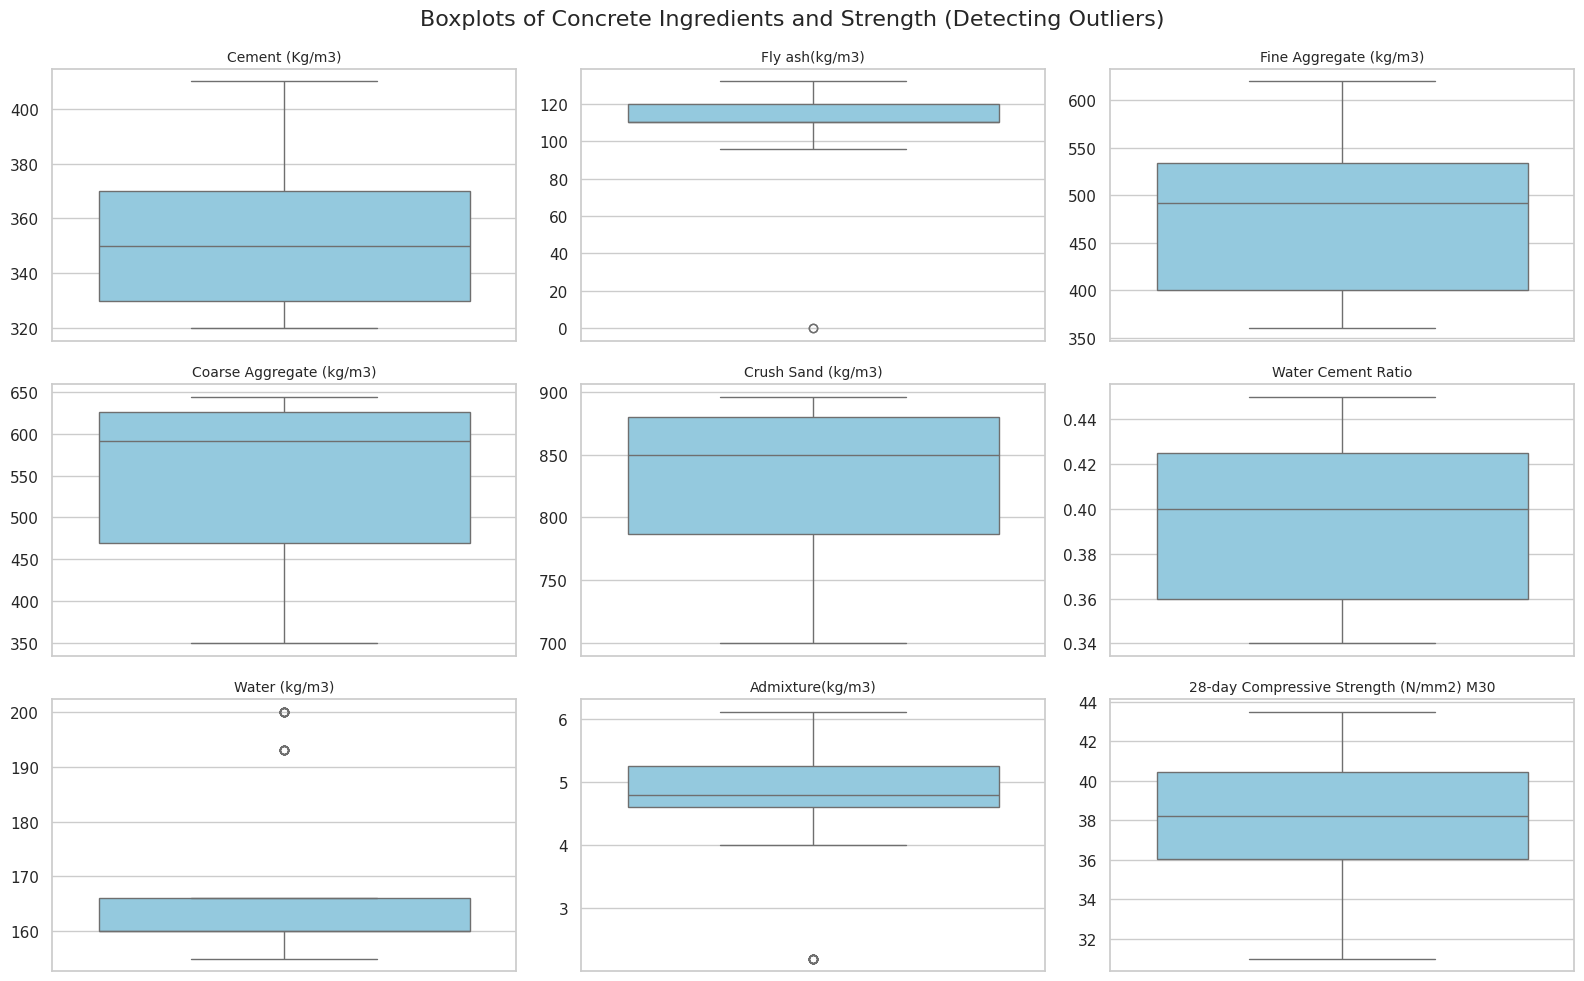

In [2]:
plt.figure(figsize=(16, 10))
plt.suptitle("Boxplots of Concrete Ingredients and Strength (Detecting Outliers)", fontsize=16)

for i, col in enumerate(df.columns):
    plt.subplot(3, 3, i + 1) # 3 rows, 3 columns grid
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col, fontsize=10)
    plt.ylabel('')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

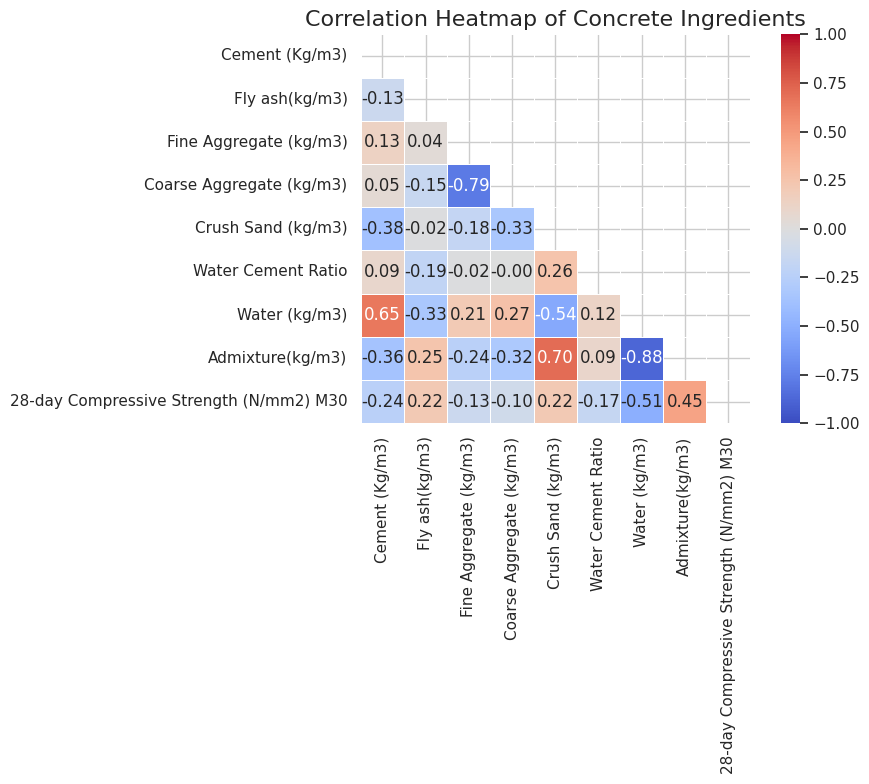

In [4]:
plt.figure(figsize=(10, 8))
plt.title("Correlation Heatmap of Concrete Ingredients", fontsize=16)

corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=.5)

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler

X = df.drop('28-day Compressive Strength (N/mm2) M30', axis=1)
y = df['28-day Compressive Strength (N/mm2) M30']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

cv_strategy = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

print("Feature Scaling Complete!")
print("Input shape:", X_scaled_df.shape)
print("Target shape:", y.shape)
print("Validation Strategy Configured:", cv_strategy)

Feature Scaling Complete!
Input shape: (111, 8)
Target shape: (111,)
Validation Strategy Configured: RepeatedKFold(n_repeats=3, n_splits=5, random_state=42)


In [6]:
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

results_dict = {}

scoring_metrics = {
    'r2': 'r2',
    'neg_rmse': 'neg_root_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error'
}

print("Results storage and metrics initialized successfully!")

Results storage and metrics initialized successfully!


In [7]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_cv = cross_validate(lr_model, X_scaled_df, y, cv=cv_strategy, scoring=scoring_metrics)

lr_r2 = lr_cv['test_r2'].mean()
lr_rmse = lr_cv['test_neg_rmse'].mean() * -1
lr_mae = lr_cv['test_neg_mae'].mean() * -1

results_dict["Linear Regression"] = {"R-Squared": lr_r2, "RMSE": lr_rmse, "MAE": lr_mae}

print("--- Linear Regression Results ---")
print(f"R-Squared: {lr_r2:.4f}")
print(f"RMSE:      {lr_rmse:.4f}")
print(f"MAE:       {lr_mae:.4f}")

--- Linear Regression Results ---
R-Squared: 0.0972
RMSE:      2.7682
MAE:       2.2921


In [8]:
# Ridge Regression
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_cv = cross_validate(ridge_model, X_scaled_df, y, cv=cv_strategy, scoring=scoring_metrics)

ridge_r2 = ridge_cv['test_r2'].mean()
ridge_rmse = ridge_cv['test_neg_rmse'].mean() * -1
ridge_mae = ridge_cv['test_neg_mae'].mean() * -1

results_dict["Ridge Regression"] = {"R-Squared": ridge_r2, "RMSE": ridge_rmse, "MAE": ridge_mae}

print("--- Ridge Regression Results ---")
print(f"R-Squared: {ridge_r2:.4f}")
print(f"RMSE:      {ridge_rmse:.4f}")
print(f"MAE:       {ridge_mae:.4f}")

--- Ridge Regression Results ---
R-Squared: 0.1134
RMSE:      2.7427
MAE:       2.2758


In [9]:
# Lasso Regression
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)
lasso_cv = cross_validate(lasso_model, X_scaled_df, y, cv=cv_strategy, scoring=scoring_metrics)

lasso_r2 = lasso_cv['test_r2'].mean()
lasso_rmse = lasso_cv['test_neg_rmse'].mean() * -1
lasso_mae = lasso_cv['test_neg_mae'].mean() * -1

results_dict["Lasso Regression"] = {"R-Squared": lasso_r2, "RMSE": lasso_rmse, "MAE": lasso_mae}

print("--- Lasso Regression Results ---")
print(f"R-Squared: {lasso_r2:.4f}")
print(f"RMSE:      {lasso_rmse:.4f}")
print(f"MAE:       {lasso_mae:.4f}")

--- Lasso Regression Results ---
R-Squared: 0.1475
RMSE:      2.6923
MAE:       2.2560


In [10]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
rf_cv = cross_validate(rf_model, X_scaled_df, y, cv=cv_strategy, scoring=scoring_metrics)

rf_r2 = rf_cv['test_r2'].mean()
rf_rmse = rf_cv['test_neg_rmse'].mean() * -1
rf_mae = rf_cv['test_neg_mae'].mean() * -1

results_dict["Random Forest"] = {"R-Squared": rf_r2, "RMSE": rf_rmse, "MAE": rf_mae}

print("--- Random Forest Results ---")
print(f"R-Squared: {rf_r2:.4f}")
print(f"RMSE:      {rf_rmse:.4f}")
print(f"MAE:       {rf_mae:.4f}")

--- Random Forest Results ---
R-Squared: 0.0114
RMSE:      2.8922
MAE:       2.3115


In [13]:
# XG Boost
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
xgb_cv = cross_validate(xgb_model, X_scaled_df, y, cv=cv_strategy, scoring=scoring_metrics)

xgb_r2 = xgb_cv['test_r2'].mean()
xgb_rmse = xgb_cv['test_neg_rmse'].mean() * -1
xgb_mae = xgb_cv['test_neg_mae'].mean() * -1

results_dict["XGBoost"] = {"R-Squared": xgb_r2, "RMSE": xgb_rmse, "MAE": xgb_mae}

print("--- XGBoost Results ---")
print(f"R-Squared: {xgb_r2:.4f}")
print(f"RMSE:      {xgb_rmse:.4f}")
print(f"MAE:       {xgb_mae:.4f}")

--- XGBoost Results ---
R-Squared: -0.3228
RMSE:      3.3435
MAE:       2.5975


In [15]:
# Support Vector Regression
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_cv = cross_validate(svr_model, X_scaled_df, y, cv=cv_strategy, scoring=scoring_metrics)

svr_r2 = svr_cv['test_r2'].mean()
svr_rmse = svr_cv['test_neg_rmse'].mean() * -1
svr_mae = svr_cv['test_neg_mae'].mean() * -1

results_dict["SVR"] = {"R-Squared": svr_r2, "RMSE": svr_rmse, "MAE": svr_mae}

print("--- SVR Results ---")
print(f"R-Squared: {svr_r2:.4f}")
print(f"RMSE:      {svr_rmse:.4f}")
print(f"MAE:       {svr_mae:.4f}")

--- SVR Results ---
R-Squared: 0.0578
RMSE:      2.8441
MAE:       2.2931


In [17]:
# Multi-Layer Perceptron
from sklearn.neural_network import MLPRegressor

mlp_model = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=2000, random_state=42)
mlp_cv = cross_validate(mlp_model, X_scaled_df, y, cv=cv_strategy, scoring=scoring_metrics)

mlp_r2 = mlp_cv['test_r2'].mean()
mlp_rmse = mlp_cv['test_neg_rmse'].mean() * -1
mlp_mae = mlp_cv['test_neg_mae'].mean() * -1

results_dict["Multi-Layer Perceptron"] = {"R-Squared": mlp_r2, "RMSE": mlp_rmse, "MAE": mlp_mae}

print("--- MLP Results ---")
print(f"R-Squared: {mlp_r2:.4f}")
print(f"RMSE:      {mlp_rmse:.4f}")
print(f"MAE:       {mlp_mae:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perce

--- MLP Results ---
R-Squared: -2.6255
RMSE:      5.1267
MAE:       3.4431


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,R-Squared,RMSE,MAE
0,Lasso Regression,0.147510,2.692334,2.256025
1,Ridge Regression,0.113437,2.742689,2.275764
2,Linear Regression,0.097234,2.768163,2.292108
3,SVR,0.057788,2.844098,2.293051
4,Random Forest,0.011417,2.892229,2.311469
5,XGBoost,-0.322829,3.343529,2.597474
6,Multi-Layer Perceptron,-2.625547,5.126674,3.443096


/tmp/ipykernel_238/2230385043.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R-Squared', y='Model', data=results_df, palette='viridis')


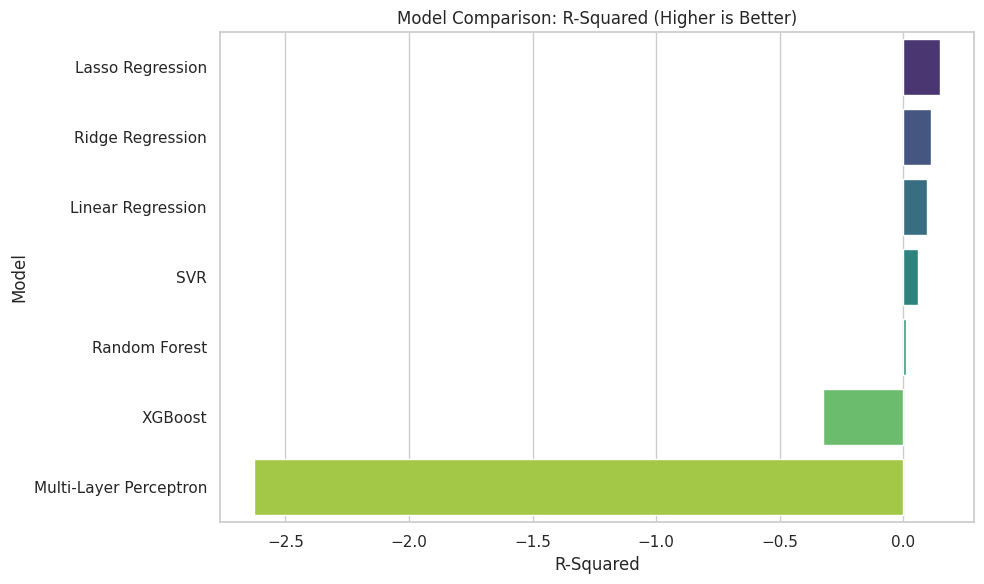

/tmp/ipykernel_238/2230385043.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE', y='Model', data=results_df, palette='magma')


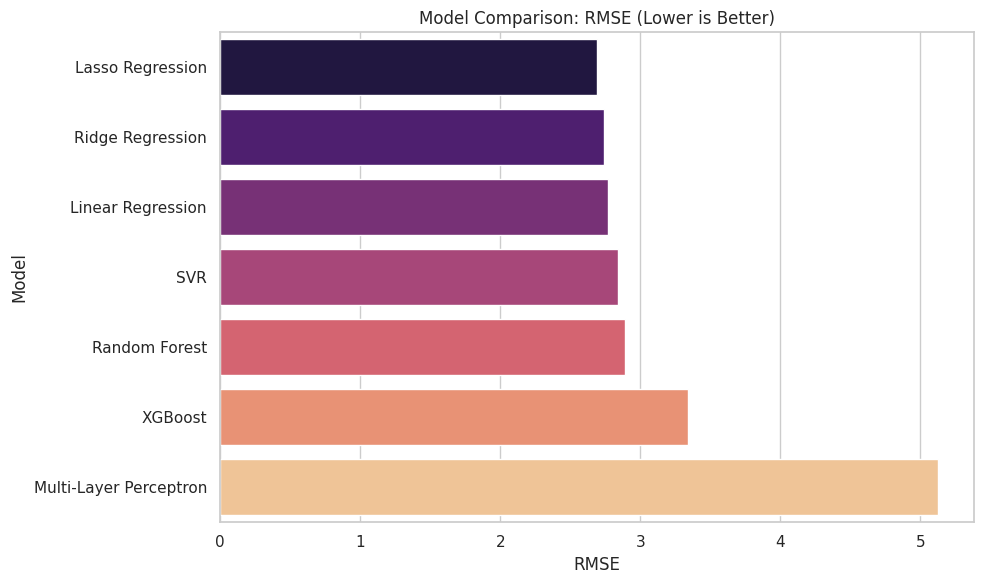

In [18]:
# Final Leaderboard and Visualizations
results_df = pd.DataFrame.from_dict(results_dict, orient='index').reset_index()
results_df.rename(columns={'index': 'Model'}, inplace=True)
results_df = results_df.sort_values(by="R-Squared", ascending=False).reset_index(drop=True)

display(results_df)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='R-Squared', y='Model', data=results_df, palette='viridis')
plt.title('Model Comparison: R-Squared (Higher is Better)')
plt.tight_layout()
plt.savefig('r2_comparison.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='RMSE', y='Model', data=results_df, palette='magma')
plt.title('Model Comparison: RMSE (Lower is Better)')
plt.tight_layout()
plt.savefig('rmse_comparison.png')
plt.show()

results_df.to_csv('comparison_results.csv', index=False)